# Finite Square Well Potential

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({'font.size':16, 'axes.labelsize':16})

The finite square well potential is very similar to the infinite square well potential, but we let the potential be $V_0$ outside of the well instead of infinity. That is, for a finite square well of length $L$, we have

$V(x) =
\begin{cases}
   V_0 && x \leq 0        \\
   0   && 0   <  x < L \\
   V_0 && x \geq L
\end{cases}$

This divides our potential into three regions, as shown below.

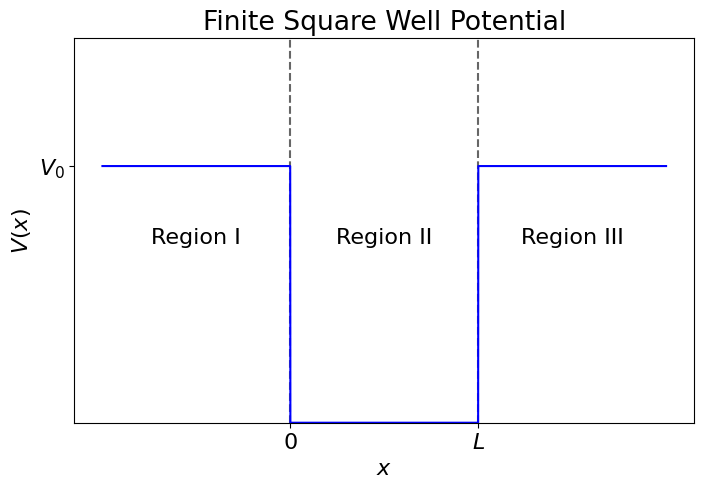

In [77]:
L = 1.0
V0 = 1.0

x = np.linspace(-L, 2*L, 3000)
V = np.full_like(x, V0)
V[1000:2000] = 0

plt.figure(figsize=(8,5))
plt.ylim(0, 1.5*V0)

plt.xticks([0, L], labels=["0", "$L$"])
plt.axvline(0, color="0.4", ls="--")
plt.axvline(L, color="0.4", ls="--")

plt.yticks([V0], labels=["$V_0$"])

plt.text(-0.5, 0.7, "Region I", horizontalalignment="center")
plt.text(0.5, 0.7, "Region II", horizontalalignment="center")
plt.text(1.5, 0.7, "Region III", horizontalalignment="center")

plt.plot(x, V, color="b")

plt.title("Finite Square Well Potential")
plt.xlabel("$x$")
plt.ylabel("$V(x)$")

plt.show()

## Regions I & III

For now, consider a particle with $E < V_0$. Classically, this would mean that the particle is bound inside the well. We will first examine its behavior in regions I and III, where $V=V_0$. Start with the Schrödinger wave equation:

$\displaystyle -\frac{\hbar^2}{2m} \frac{d^2 \psi(x)}{dx^2} + V_0 \psi(x) = E \psi(x)$.

We can subtract $V_0\psi(x)$ and divide by $-\hbar^2/2m$ to find that

$\displaystyle \frac{d^2\psi(x)}{dx^2} = \frac{2m(V_0-E)}{\hbar^2}\psi(x)$.

Take a constant $\alpha^2 = 2m(V_0-E)/\hbar^2$. This works since $V_0-E$ is positive. Then, our equation is

$\displaystyle \frac{d^2\psi(x)}{dx^2} = \alpha^2\psi(x)$.

The solutions of this differential equation have the form $Ae^{\alpha x} + Be^{-\alpha x}$. However, in region I, the negative exponential term would give an infinite $\psi(x)$ as $x\to-\infty$, which is not valid. Similarly, in region III, the positive exponential term would give an infinite $\psi(x)$ as $x\to\infty$. So, we only take $\psi(x) = Ae^{\alpha x}$ in region I and $\psi(x) = Be^{-\alpha x}$ in region III.

## Region II

Now, we examine the particle's behavior in region II, where $V=0$. This time, the Schrödinger wave equation is just

$\displaystyle -\frac{\hbar^2}{2m} \frac{d^2 \psi(x)}{dx^2} = E \psi(x)$,

and we can see that

$\displaystyle \frac{d^2\psi(x)}{dx^2} = -\frac{2mE}{\hbar^2}\psi(x)$.

Take $k^2 = 2mE/\hbar^2$, and substitute it to get

$\displaystyle \frac{d^2\psi(x)}{dx^2} = -k^2\psi(x)$.

So, for Region II, our solution looks like $\psi(x) = C\sin(kx)+D\cos(kx)$.

## Observations

As we have just shown, our wave function can be written in the form

$\psi(x) =
\begin{cases}
   Ae^{\alpha x}       && x \leq 0        \\
   C\sin(kx)+D\cos(kx) && 0 \leq x \leq L \\
   Be^{-\alpha x}      && x \geq L
\end{cases}$

Additionally, in order to be a valid wave function, $\psi(x)$ and $\frac{d\psi(x)}{dx}$ must be continuous at $x=0$ and $x=L$. This restriction leads to a quantization of energy levels $E_n$ and the wave function $\psi_n$. A plot of what a possible wave function could look like is given below.

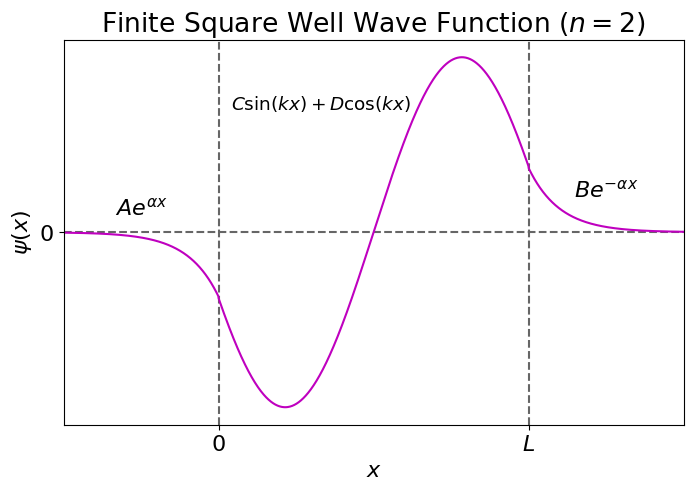

In [178]:
L = 1.0
x = np.linspace(-L, 2*L, 3000)

# not a true wave function, but approximates the shape of one enough to be a visual aide
# continuous exponential -> trig -> exponential piecewise
psi = np.piecewise(x,
    [x <= 0, (x > 0) & (x < L), x >= L],
    [lambda x: -np.exp((10*x)-L),
     lambda x: -np.sin(2*np.pi* (x+0.07) / (L+0.14)),
     lambda x: np.exp(-10*x+9*L)]
)
        
plt.figure(figsize=(8,5))

plt.xticks([0, L], labels=["0", "$L$"])
plt.axvline(0, color="0.4", ls="--")
plt.axvline(L, color="0.4", ls="--")

plt.yticks([0], labels=["0"])
plt.axhline(0, color="0.4", ls="--")

plt.text(-0.25, 0.1, r"$Ae^{\alpha x}$", horizontalalignment="center")
plt.text(0.33, 0.7, r"$C\sin(kx)+D\cos(kx)$", size="small", horizontalalignment="center")
plt.text(1.25, 0.2, r"$Be^{-\alpha x}$", horizontalalignment="center")

plt.plot(x, psi, color="m")
plt.xlim(-0.5, L+0.5)

plt.title("Finite Square Well Wave Function ($n=2$)")
plt.xlabel("$x$")
plt.ylabel(r"$\psi(x)$")

plt.show()

Notice that unlike with the infinite square well potential, $\psi(x)$ is not $0$ everywhere outside of the well. This means that according to our quantum description, the particle actually has a nonzero probability of being outside of the well when $E < V_0$, even though classical mechanics tells us this should be impossible. It should be noted that it is unlikely for the particle to be far outside of the well, since our wave function decays exponentially.